# P2 - Data Understanding and Exploratory Data Analysis

**Project:** diabetes-risk-ml - an academic ML portfolio project estimating self-reported diabetes/prediabetes risk from BRFSS 2015 health indicators.

> This project is not a medical device and must not be used for diagnosis or medical advice.

## Scope of this notebook

This notebook implements Epic **E2: Data Understanding and EDA** (see `docs/backlog.md` and `docs/ml-analysis-plan.md`). It only produces evidence for later data preparation and modeling decisions.

It does **not**:
- Train any model.
- Create train/calibration/test splits.
- Apply balancing, SMOTE, calibration, SHAP, or Streamlit work.
- Permanently drop duplicate rows.
- Permanently change column dtypes.
- Remove or select features based on correlation.

Any cleaning, validation, or split implications identified here are recorded as candidate tasks for **P3: Data Preparation and Splits**.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)

RANDOM_STATE = 42

## 1. Load the Dataset

The raw CSV is git-ignored and must be downloaded manually (see `data/README.md`). We fail loudly if it is missing instead of silently generating fake data.

In [2]:
CANDIDATE_PATHS = [
    Path("data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"),
    Path("../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"),
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Raw dataset not found. Expected 'data/raw/diabetes_binary_health_indicators_BRFSS2015.csv' "
        "relative to the project root (checked from both the repo root and 'notebooks/'). "
        "Download it manually from Kaggle and place it at that path -- see data/README.md."
    )

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH.as_posix()}")
print(f"Shape: {df.shape}")

Loaded dataset from: ../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv
Shape: (253680, 22)


## 2. Shape and Schema Validation

In [3]:
TARGET = "Diabetes_binary"

BINARY_FEATURES = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
    "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies",
    "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex",
]
ORDINAL_FEATURES = ["GenHlth", "Age", "Education", "Income"]
NUMERIC_FEATURES = ["BMI", "MentHlth", "PhysHlth"]

EXPECTED_COLUMNS = {TARGET, *BINARY_FEATURES, *ORDINAL_FEATURES, *NUMERIC_FEATURES}

n_rows, n_cols = df.shape
print(f"Rows: {n_rows:,}")
print(f"Columns: {n_cols}")

missing_expected = EXPECTED_COLUMNS - set(df.columns)
unexpected_columns = set(df.columns) - EXPECTED_COLUMNS

assert n_rows == 253_680, f"Unexpected row count: {n_rows:,} (expected 253,680 per data/README.md)"
assert n_cols == 22, f"Unexpected column count: {n_cols} (expected 22)"
assert not missing_expected, f"Missing expected columns: {sorted(missing_expected)}"
assert not unexpected_columns, f"Unexpected columns found: {sorted(unexpected_columns)}"

print("\nAll 22 documented columns are present, and no unexpected columns were found.")
print("\nRaw column order (as stored in the CSV):")
print(list(df.columns))

Rows: 253,680
Columns: 22

All 22 documented columns are present, and no unexpected columns were found.

Raw column order (as stored in the CSV):
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


**Note:** the raw file does not group columns by type -- binary, ordinal, and numeric indicators are interleaved in survey order. This is expected. The feature groups defined above (`BINARY_FEATURES`, `ORDINAL_FEATURES`, `NUMERIC_FEATURES`) are the modeling-relevant grouping and are used consistently for the rest of this notebook and in P3.

## 3. Target Validation

In [4]:
target_values = sorted(df[TARGET].unique())
print(f"{TARGET} dtype: {df[TARGET].dtype}")
print(f"{TARGET} unique values: {target_values}")

assert target_values == [0.0, 1.0], f"Unexpected target values: {target_values}"
assert df[TARGET].isna().sum() == 0, "Target contains missing values"

print("\nTarget is strictly binary (0.0 / 1.0) with no missing values.")

Diabetes_binary dtype: float64
Diabetes_binary unique values: [0.0, 1.0]

Target is strictly binary (0.0 / 1.0) with no missing values.


## 4. Feature Grouping

In [5]:
print(f"Binary indicators ({len(BINARY_FEATURES)}): {BINARY_FEATURES}")
print(f"\nOrdinal indicators ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}")
print(f"\nNumeric indicators ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")

assert len(BINARY_FEATURES) + len(ORDINAL_FEATURES) + len(NUMERIC_FEATURES) + 1 == n_cols

Binary indicators (14): ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

Ordinal indicators (4): ['GenHlth', 'Age', 'Education', 'Income']

Numeric indicators (3): ['BMI', 'MentHlth', 'PhysHlth']


## 5. Data Type Review

In [6]:
dtype_summary = df.dtypes.value_counts()
print("Column count by dtype:")
print(dtype_summary)
print("\nAll columns are stored as float64, which is wider than necessary for binary/ordinal/"
      "small-integer features. See Section 12 for memory and downcasting analysis.")

Column count by dtype:
float64    22
Name: count, dtype: int64

All columns are stored as float64, which is wider than necessary for binary/ordinal/small-integer features. See Section 12 for memory and downcasting analysis.


## 6. Feature Range and Unexpected Value Checks

In [7]:
print("Binary feature value checks (expected: subset of {0.0, 1.0}):")
binary_issues = {}
for col in BINARY_FEATURES:
    values = set(df[col].unique())
    if not values <= {0.0, 1.0}:
        binary_issues[col] = sorted(values)
    print(f"  {col}: {sorted(values)}")

if binary_issues:
    print(f"\nUnexpected binary values found: {binary_issues}")
else:
    print("\nAll binary indicators contain only 0.0 / 1.0 as expected.")

Binary feature value checks (expected: subset of {0.0, 1.0}):
  HighBP: [0.0, 1.0]
  HighChol: [0.0, 1.0]
  CholCheck: [0.0, 1.0]
  Smoker: [0.0, 1.0]
  Stroke: [0.0, 1.0]
  HeartDiseaseorAttack: [0.0, 1.0]
  PhysActivity: [0.0, 1.0]
  Fruits: [0.0, 1.0]
  Veggies: [0.0, 1.0]
  HvyAlcoholConsump: [0.0, 1.0]
  AnyHealthcare: [0.0, 1.0]
  NoDocbcCost: [0.0, 1.0]
  DiffWalk: [0.0, 1.0]
  Sex: [0.0, 1.0]

All binary indicators contain only 0.0 / 1.0 as expected.


In [8]:
ORDINAL_EXPECTED_RANGES = {
    "GenHlth": (1, 5),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8),
}

print("Ordinal feature range checks:")
for col, (lo, hi) in ORDINAL_EXPECTED_RANGES.items():
    observed_min, observed_max = df[col].min(), df[col].max()
    in_range = (observed_min >= lo) and (observed_max <= hi)
    print(f"  {col}: observed [{observed_min:.0f}, {observed_max:.0f}] | expected [{lo}, {hi}] | OK={in_range}")
    assert in_range, f"{col} out of documented range"


Ordinal feature range checks:
  GenHlth: observed [1, 5] | expected [1, 5] | OK=True
  Age: observed [1, 13] | expected [1, 13] | OK=True
  Education: observed [1, 6] | expected [1, 6] | OK=True
  Income: observed [1, 8] | expected [1, 8] | OK=True


In [9]:
NUMERIC_EXPECTED_RANGES = {
    "BMI": (12, 98),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
}

print("Numeric feature range checks:")
for col, (lo, hi) in NUMERIC_EXPECTED_RANGES.items():
    observed_min, observed_max = df[col].min(), df[col].max()
    in_range = (observed_min >= lo) and (observed_max <= hi)
    print(f"  {col}: observed [{observed_min:.1f}, {observed_max:.1f}] | expected [{lo}, {hi}] | OK={in_range}")
    assert in_range, f"{col} out of documented range"

print("\nNote: BMI, MentHlth, and PhysHlth are self-reported survey values (BMI is respondent-derived "
      "from self-reported height/weight; MentHlth/PhysHlth count 'poor health days' in the last 30 days). "
      "All observed values fall within plausible survey bounds, and all three columns are whole numbers "
      "despite being stored as float64 (see Section 12).")

Numeric feature range checks:
  BMI: observed [12.0, 98.0] | expected [12, 98] | OK=True
  MentHlth: observed [0.0, 30.0] | expected [0, 30] | OK=True
  PhysHlth: observed [0.0, 30.0] | expected [0, 30] | OK=True

Note: BMI, MentHlth, and PhysHlth are self-reported survey values (BMI is respondent-derived from self-reported height/weight; MentHlth/PhysHlth count 'poor health days' in the last 30 days). All observed values fall within plausible survey bounds, and all three columns are whole numbers despite being stored as float64 (see Section 12).


## 7. Missing Value Analysis

In [10]:
missing_counts = df.isna().sum()
total_missing = missing_counts.sum()

print(f"Total missing values across all columns: {total_missing}")
if total_missing:
    print(missing_counts[missing_counts > 0])
else:
    print("No missing values found in any column.")

Total missing values across all columns: 0
No missing values found in any column.


## 8. Duplicate Rows

In [11]:
n_in_duplicate_groups = df.duplicated(keep=False).sum()  # all rows involved in a duplicate set
n_would_drop = df.duplicated(keep="first").sum()          # rows drop_duplicates() would remove

print(f"Rows involved in some duplicate group: {n_in_duplicate_groups:,} ({n_in_duplicate_groups / n_rows:.2%})")
print(f"Rows drop_duplicates() would remove (all but first occurrence): {n_would_drop:,} ({n_would_drop / n_rows:.2%})")

target_rate_overall = df[TARGET].mean() * 100
target_rate_in_groups = df.loc[df.duplicated(keep=False), TARGET].mean() * 100
target_rate_would_drop = df.loc[df.duplicated(keep="first"), TARGET].mean() * 100

print(f"\nPositive rate overall: {target_rate_overall:.2f}%")
print(f"Positive rate among rows in a duplicate group: {target_rate_in_groups:.2f}%")
print(f"Positive rate among rows that would be dropped: {target_rate_would_drop:.2f}%")

hypothetical = df.drop_duplicates(keep="first")  # illustrative only; df itself is left untouched
print(f"\nIf duplicates were dropped (not applied here): {len(hypothetical):,} rows would remain, "
      f"positive rate would shift to {hypothetical[TARGET].mean() * 100:.2f}%")
del hypothetical

Rows involved in some duplicate group: 35,575 (14.02%)
Rows drop_duplicates() would remove (all but first occurrence): 24,206 (9.54%)



Positive rate overall: 13.93%
Positive rate among rows in a duplicate group: 1.35%
Positive rate among rows that would be dropped: 1.03%

If duplicates were dropped (not applied here): 229,474 rows would remain, positive rate would shift to 15.29%


**Interpretation:** duplicate rows are strongly skewed toward the **negative** class (~1% positive rate among duplicated rows, vs. ~13.9% overall). This is consistent with a low-cardinality feature space: mostly-binary/ordinal features mean "unremarkable" negative-class respondents share far more identical value combinations than the more varied, higher-comorbidity positive-class respondents. Exact-row collisions here look like a property of the survey's coarse feature space, not obvious evidence of corrupted or accidentally re-entered records.

This is still a materially important finding for P3: dropping duplicates would shrink the dataset by about 9.5% **and** raise the positive prevalence from ~13.9% to ~15.3%. No rows are dropped in this notebook -- the duplicate-handling policy (keep vs. drop, and why) is deferred to P3 as an explicit, documented decision that must account for this prevalence shift.

## 9. Target Distribution and Prevalence

In [12]:
target_counts = df[TARGET].value_counts().sort_index()
target_pct = df[TARGET].value_counts(normalize=True).sort_index() * 100

print("Target counts:")
print(target_counts)
print("\nTarget percentage:")
print(target_pct.round(2))

positive_rate = target_pct.loc[1.0]
print(f"\nPositive class ('has diabetes/prediabetes') prevalence: {positive_rate:.2f}%")
print(f"A trivial classifier predicting the majority class for every row would score "
      f"~{100 - positive_rate:.1f}% accuracy while never detecting a positive case.")

Target counts:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Target percentage:
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

Positive class ('has diabetes/prediabetes') prevalence: 13.93%
A trivial classifier predicting the majority class for every row would score ~86.1% accuracy while never detecting a positive case.


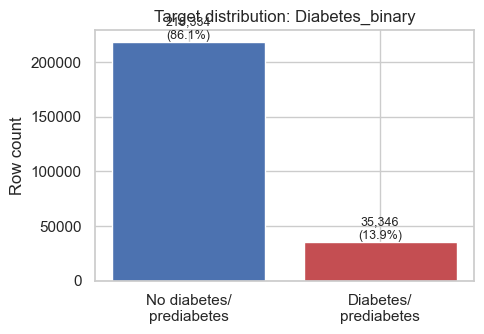

In [13]:
fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["No diabetes/\nprediabetes", "Diabetes/\nprediabetes"]
ax.bar(labels, target_counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 3000, f"{v:,}\n({target_pct.values[i]:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("Row count")
ax.set_title("Target distribution: Diabetes_binary")
plt.tight_layout()
plt.show()

## 10. Descriptive Summaries for Key Variables

count    253680.00
mean         28.38
std           6.61
min          12.00
25%          24.00
50%          27.00
75%          31.00
max          98.00
Name: BMI, dtype: float64


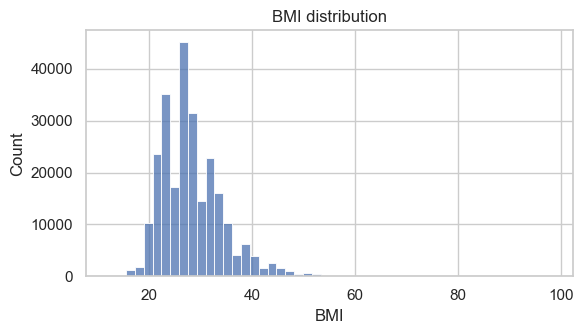

In [14]:
print(df["BMI"].describe().round(2))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(df["BMI"], bins=50, ax=ax, color="#4C72B0")
ax.set_title("BMI distribution")
ax.set_xlabel("BMI")
plt.tight_layout()
plt.show()

Diabetes/prediabetes rate (%) by self-reported general health (1=Excellent ... 5=Poor):
GenHlth
1.0     2.5
2.0     7.2
3.0    17.8
4.0    31.0
5.0    37.9
Name: Diabetes_binary, dtype: float64


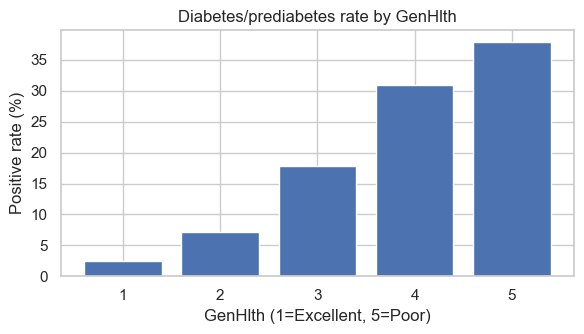

In [15]:
genhlth_rate = df.groupby("GenHlth")[TARGET].mean() * 100
print("Diabetes/prediabetes rate (%) by self-reported general health (1=Excellent ... 5=Poor):")
print(genhlth_rate.round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(genhlth_rate.index.astype(int).astype(str), genhlth_rate.values, color="#4C72B0")
ax.set_xlabel("GenHlth (1=Excellent, 5=Poor)")
ax.set_ylabel("Positive rate (%)")
ax.set_title("Diabetes/prediabetes rate by GenHlth")
plt.tight_layout()
plt.show()

Diabetes/prediabetes rate (%) by age group code (1=18-24 ... 13=80+):
Age
1.0      1.4
2.0      1.8
3.0      2.8
4.0      4.5
5.0      6.5
6.0      8.8
7.0     11.7
8.0     13.8
9.0     17.2
10.0    20.4
11.0    21.8
12.0    21.3
13.0    18.5
Name: Diabetes_binary, dtype: float64


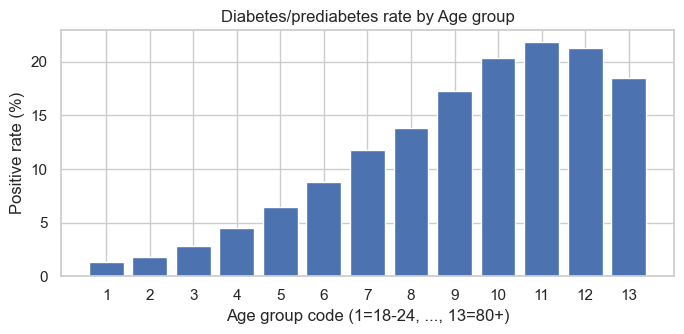

In [16]:
age_rate = df.groupby("Age")[TARGET].mean() * 100
print("Diabetes/prediabetes rate (%) by age group code (1=18-24 ... 13=80+):")
print(age_rate.round(1))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(age_rate.index.astype(int).astype(str), age_rate.values, color="#4C72B0")
ax.set_xlabel("Age group code (1=18-24, ..., 13=80+)")
ax.set_ylabel("Positive rate (%)")
ax.set_title("Diabetes/prediabetes rate by Age group")
plt.tight_layout()
plt.show()

Diabetes/prediabetes rate (%) by income group code (1=lowest ... 8=highest):
Income
1.0    24.3
2.0    26.2
3.0    22.3
4.0    20.1
5.0    17.4
6.0    14.5
7.0    12.2
8.0     8.0
Name: Diabetes_binary, dtype: float64


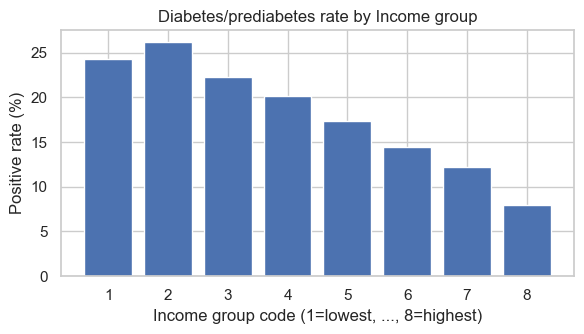

In [17]:
income_rate = df.groupby("Income")[TARGET].mean() * 100
print("Diabetes/prediabetes rate (%) by income group code (1=lowest ... 8=highest):")
print(income_rate.round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(income_rate.index.astype(int).astype(str), income_rate.values, color="#4C72B0")
ax.set_xlabel("Income group code (1=lowest, ..., 8=highest)")
ax.set_ylabel("Positive rate (%)")
ax.set_title("Diabetes/prediabetes rate by Income group")
plt.tight_layout()
plt.show()

In [18]:
highbp_rate = df.groupby("HighBP")[TARGET].mean() * 100
print("Diabetes/prediabetes rate (%) by HighBP:")
print(highbp_rate.rename({0.0: "No HighBP", 1.0: "HighBP"}).round(1))

Diabetes/prediabetes rate (%) by HighBP:
HighBP
No HighBP     6.0
HighBP       24.4
Name: Diabetes_binary, dtype: float64


**Observations:** the positive-class rate rises fairly monotonically with worse self-reported general health (`GenHlth`), older age groups, and lower income, and is markedly higher among respondents with `HighBP`. These are descriptive associations in self-reported survey data, not causal claims.

## 11. Spearman Correlation Review

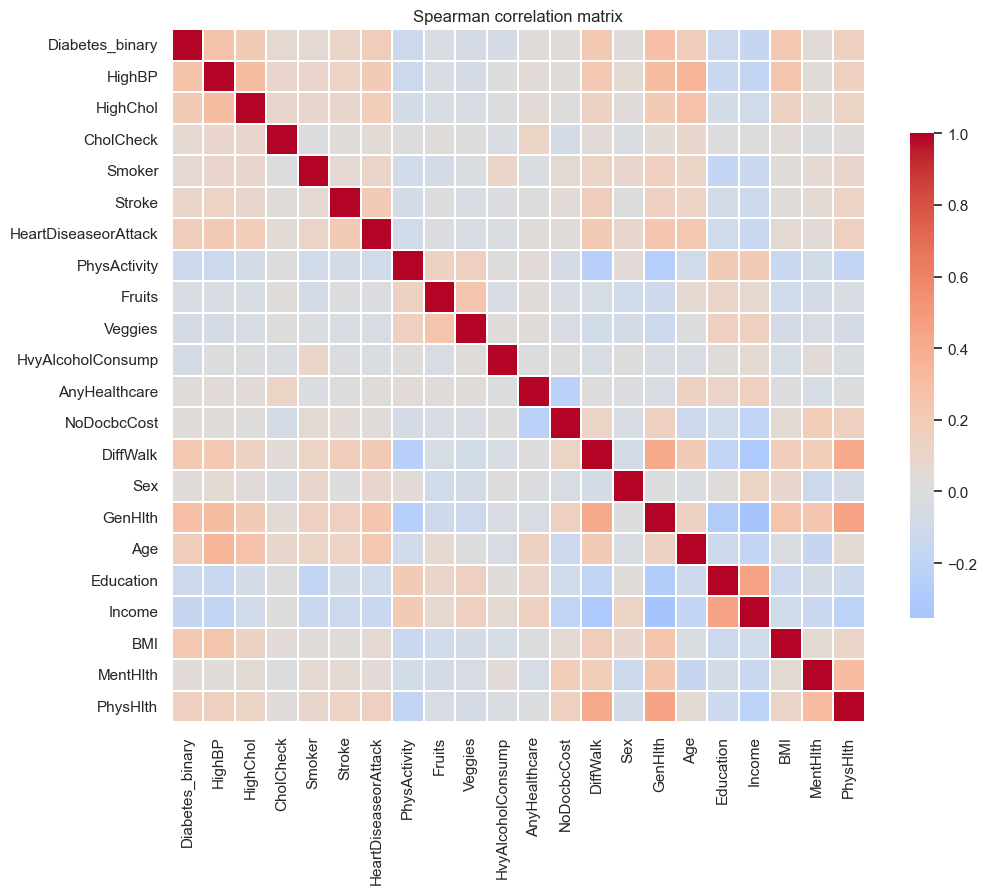

In [19]:
FEATURE_COLUMNS = BINARY_FEATURES + ORDINAL_FEATURES + NUMERIC_FEATURES
corr = df[[TARGET] + FEATURE_COLUMNS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation matrix")
plt.tight_layout()
plt.show()

In [20]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("Feature correlation with target (Spearman), sorted by |correlation|:")
print(target_corr.round(3))

Feature correlation with target (Spearman), sorted by |correlation|:
GenHlth                 0.288
HighBP                  0.263
BMI                     0.226
DiffWalk                0.218
HighChol                0.200
Age                     0.178
HeartDiseaseorAttack    0.177
Income                 -0.163
PhysHlth                0.157
Education              -0.120
PhysActivity           -0.118
Stroke                  0.106
CholCheck               0.065
Smoker                  0.061
HvyAlcoholConsump      -0.057
Veggies                -0.057
Fruits                 -0.041
MentHlth                0.040
NoDocbcCost             0.031
Sex                     0.031
AnyHealthcare           0.016
Name: Diabetes_binary, dtype: float64


In [21]:
feature_corr = corr.loc[FEATURE_COLUMNS, FEATURE_COLUMNS].copy()
np.fill_diagonal(feature_corr.values, 0)

pairs = (
    feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
    .stack()
    .rename("spearman_corr")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
strong_pairs = pairs.loc[pairs["spearman_corr"].abs() >= 0.4].sort_values("spearman_corr", key=abs, ascending=False)

print("Feature pairs with |Spearman correlation| >= 0.4 (possible redundancy, not acted on in E2):")
print(strong_pairs.to_string(index=False))

Feature pairs with |Spearman correlation| >= 0.4 (possible redundancy, not acted on in E2):
feature_1 feature_2  spearman_corr
Education    Income          0.452
  GenHlth  PhysHlth          0.452
 DiffWalk   GenHlth          0.423
 DiffWalk  PhysHlth          0.415


**Observations:** no single feature is strongly correlated with the target in isolation -- consistent with a multifactorial health outcome -- though `GenHlth`, `HighBP`, `BMI`, `DiffWalk`, `HighChol`, and `Age` show the strongest individual associations. A few feature pairs (general health vs. physical-health days / difficulty walking, education vs. income) are moderately correlated, which is expected given their conceptual overlap. No features are removed or selected based on this review; redundancy is only flagged here as input to P3 preprocessing and model choice (e.g., regularization or tree-based models tolerate moderate collinearity better than plain linear models).

## 12. Memory Usage and Downcasting Recommendations

In [22]:
current_memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Current in-memory size (all columns as float64): {current_memory_mb:.2f} MB")

# Preview only: every column holds whole numbers within [0, 98], so uint8 covers the full
# observed range for all 22 columns. This is NOT applied to `df` -- P3 owns the real conversion.
downcast_preview = df.astype("uint8")

preview_memory_mb = downcast_preview.memory_usage(deep=True).sum() / 1024**2
reduction_pct = (1 - preview_memory_mb / current_memory_mb) * 100

print(f"Projected size if every column were downcast to uint8: {preview_memory_mb:.2f} MB")
print(f"Projected reduction: {reduction_pct:.1f}%")

# Sanity check: confirm the preview downcast did not silently change any value.
assert (downcast_preview.values == df.values).all(), "Downcast preview altered values -- do not use uint8 blindly"

del downcast_preview

Current in-memory size (all columns as float64): 42.58 MB
Projected size if every column were downcast to uint8: 5.32 MB
Projected reduction: 87.5%


**Recommendation for P3:** every column is currently stored as `float64` even though every observed value is a whole number in a narrow range (confirmed above via the round-trip equality check). Downcasting all columns to `uint8` is projected to cut memory usage substantially (see the printed percentage above) with no observed loss of information. This should be implemented as an explicit, tested step in the P3 data-loading module (e.g. `src/data.py`) -- validated against the documented ranges from Sections 6-7 so that a future schema change (e.g. a feature that legitimately needs values above 255) cannot silently truncate data.

## 13. Why Accuracy Alone Is Insufficient

The positive class ("has diabetes or prediabetes") makes up only ~13.9% of rows. A classifier that always predicts "no diabetes" would score roughly 86% accuracy while catching **zero** true positive cases -- the opposite of what a health-risk screening tool should do.

For an imbalanced classification problem like this:

- **Accuracy** rewards the model for getting the majority class right and can look excellent even when the model is useless for the minority (at-risk) class.
- **Recall for the positive class** matters because missing an at-risk respondent (a false negative) is generally more costly than a false alarm in a screening context.
- **Precision for the positive class**, **F1**, **ROC-AUC**, and **PR-AUC** (average precision) give a more honest picture of how well the model separates and ranks at-risk respondents; PR-AUC in particular is more informative than ROC-AUC under heavy class imbalance.
- The **confusion matrix at a chosen decision threshold** makes the false-negative/false-positive trade-off explicit and reviewable.

This is why `docs/ml-analysis-plan.md` lists ROC-AUC, PR-AUC, positive-class recall/precision/F1, and the confusion matrix as primary metrics, keeping accuracy only as secondary context.

## 14. Summary of Findings and P3 Follow-Up Recommendations

### Key findings

- Shape, column count, target column, and all documented feature groups match expectations; no unexpected columns or out-of-range values were found.
- No missing values in any column.
- 24,206 rows (~9.5%) are exact duplicates of another row (`drop_duplicates()` semantics). Duplicated rows are heavily skewed toward the negative class (~1% positive vs. ~13.9% overall); dropping them would raise prevalence to ~15.3%. No rows were dropped in this notebook.
- Target prevalence is ~13.9% positive, confirming this is a meaningfully imbalanced binary classification problem.
- `GenHlth`, `HighBP`, `BMI`, `DiffWalk`, `HighChol`, and `Age` show the strongest individual (Spearman) associations with the target; a few feature pairs show moderate redundancy but were not removed.
- All columns are stored as `float64` while holding only whole numbers in `[0, 98]`; downcasting to `uint8` is projected to meaningfully reduce memory usage with no observed loss of information.

### Recommended P3 tasks

- Decide and document an explicit duplicate-row policy (keep vs. drop) with rationale, accounting for the ~13.9% -> ~15.3% prevalence shift if duplicates are dropped.
- Implement the `uint8` downcasting recommendation inside a reusable, tested data-loading module (e.g. `src/data.py`), validated against the documented ranges from Sections 6-7.
- Build the stratified train (70%) / calibration (10%) / test (20%) split described in `docs/ml-analysis-plan.md`, preserving the ~13.9% (or ~15.3%, depending on the duplicate decision) positive prevalence in every split, especially the test set.
- Carry the correlation observations (Section 11) into preprocessing/model choice discussions without pre-emptively dropping features.
- Add pytest coverage for schema/range/target validation and split class-proportion checks, per the testing plan in `docs/ml-analysis-plan.md`.